# Часть 1

## Описание проекта и данных

В рамках проекта решается задача uplift-моделирования для сервиса Яндекс Еда. Необходимо определить пользователей, которым стоит отправить промокод на 500 рублей на доставку еды из ресторанов. Цель такого воздействия — повысить частоту заказов и, как следствие, выручку компании.

Задача относится к области целевого маркетинга. В отличие от обычной бинарной классификации, здесь важно не просто предсказать вероятность конверсии, а оценить **инкрементальный эффект воздействия**: кто действительно совершит целевое действие именно благодаря промокоду, а не сделал бы это и без него.

Бизнес-цель проекта — построить систему, которая позволит точнее выбирать целевую аудиторию для маркетинговой кампании и снизить неэффективные расходы на промокоды.

ML-цель проекта — разработать uplift-модель на основе результатов A/B-теста и оценить её качество по метрике **Uplift@30**, а также дополнительным uplift-метрикам.

### Описание датасета

Датасет содержит информацию о **64 000 клиентах**, которые совершили последнюю покупку в течение последних 12 месяцев. Все пользователи участвовали в A/B-тесте в мобильном канале.

В наборе данных представлены как признаки клиентов, так и информация о маркетинговом воздействии и целевом результате.

### Признаки датасета

**recency**
Количество месяцев с момента последней покупки. Признак отражает давность активности клиента и может служить индикатором вовлечённости.

**history_segment**
Категориальный сегмент расходов клиента за последний год. Позволяет отнести клиента к определённой группе по уровню трат.

**history**
Фактическая сумма расходов клиента за последний год в долларах. Характеризует финансовую активность пользователя.

**mens**
Бинарный признак: 1, если клиент за последний год покупал товары для мужчин, иначе 0.

**womens**
Бинарный признак: 1, если клиент за последний год покупал товары для женщин, иначе 0.

**zip_code**
Категория почтового индекса: город, пригород или сельская местность. Может отражать географические особенности поведения клиентов.

**newbie**
Бинарный признак: 1, если клиент является новым за последние 12 месяцев, иначе 0.

**channel**
Канал покупок клиента за последний год:

* 0 — мультиканал
* 1 — мобильный
* 2 — веб

**treatment**
Бинарный индикатор маркетингового воздействия:

* 1 — клиент получил промокод
* 0 — клиент не получил промокод

**target**
Целевая переменная:

* 1 — клиент использовал промокод
* 0 — клиент не использовал промокод

### Что будет сделано в части 1

В первой части проекта планируется:

1. выполнить первичную подготовку данных;
2. провести исследовательский анализ данных;
3. проверить статистические различия между контрольной и тестовой группами;
4. обучить baseline uplift-модель;
5. сравнить baseline с другими uplift-подходами.

### Особенности задачи uplift-моделирования

Ключевая особенность проекта состоит в том, что нас интересует не просто склонность клиента к конверсии, а изменение этой склонности под действием промокода. Поэтому при анализе и моделировании особое внимание будет уделяться:

* различиям между контрольной и тестовой группами;
* распределению целевой переменной внутри групп;
* качеству ранжирования клиентов по ожидаемому uplift-эффекту.

Ключевая величина в uplift-моделировании — это индивидуальный эффект воздействия, который можно формализовать следующим образом:

$$
Uplift(x) = P(target = 1 \mid treatment = 1, x) - P(target = 1 \mid treatment = 0, x)
$$

где:

- $P(target = 1 \mid treatment = 1, x)$ — вероятность конверсии при наличии воздействия;
- $P(target = 1 \mid treatment = 0, x)$ — вероятность конверсии без воздействия.

Таким образом, uplift показывает, насколько изменяется вероятность целевого действия под влиянием промокода для конкретного клиента.

### Ожидаемый результат

Итогом работы должна стать uplift-модель, способная выделять клиентов, для которых отправка промокода действительно экономически оправдана. Это позволит повысить конверсию кампании и улучшить эффективность маркетинговых затрат.

## Этап 1

### Импорт библиотек

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.meta import BaseRClassifier, BaseXClassifier

from tqdm.auto import tqdm
import gc

from utils import custom_uplift_by_percentile

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

from sklearn.ensemble import RandomForestClassifier

# настройки отображения
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

### Загрузка данных

In [7]:
df = pd.read_csv('uplift_fp_data.csv')

# посмотрим на первые строки
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
0,10,1,142.44,1,0,1,0,1,1,0
1,6,2,329.08,1,1,2,1,2,0,0
2,7,1,180.65,0,1,1,1,2,1,0
3,9,4,675.83,1,0,2,1,2,0,0
4,2,0,45.34,1,0,0,0,2,1,0


In [5]:
df.columns

Index(['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code',
       'newbie', 'channel', 'treatment', 'target'],
      dtype='object')

### Общая информация о датасете

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  int64  
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  int64  
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  int64  
 8   treatment        64000 non-null  int64  
 9   target           64000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 4.9 MB


In [7]:
df.describe()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,1.481969,242.085656,0.551031,0.549719,0.748469,0.502250,1.319609,0.334172,0.146781
std,3.507592,1.544514,256.158608,0.497393,0.497526,0.697936,0.499999,0.678254,0.471704,0.353890
min,1.000000,0.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,64.660000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,6.000000,1.000000,158.110000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,9.000000,2.000000,325.657500,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,0.000000
max,12.000000,6.000000,3345.930000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000


In [8]:
df.shape

(64000, 10)

### Проверка пропусков

In [9]:
missing = df.isnull().sum()
missing[missing > 0]

Series([], dtype: int64)

### Выводы по первичной подготовке данных

На данном этапе была выполнена первичная подготовка данных.

Датасет содержит 64 000 наблюдений и 10 признаков. Все признаки имеют корректные типы данных: числовые (int64 и float64), что упрощает дальнейший анализ и моделирование.

Пропуски в данных отсутствуют, что подтверждается проверкой с использованием метода isnull(). Таким образом, дополнительная обработка пропущенных значений не требуется.

Распределение признаков выглядит корректным:
- признак `recency` варьируется от 1 до 12 месяцев;
- признак `history` имеет широкий диапазон значений, что может потребовать дополнительного анализа (например, лог-преобразования);
- бинарные признаки (`mens`, `womens`, `newbie`, `treatment`, `target`) представлены в виде 0/1;
- категориальные признаки (`history_segment`, `zip_code`, `channel`) закодированы численно.

Данные готовы для проведения исследовательского анализа (EDA).

## Этап 2

### EDA


#### 1. Баланс treatment и target

In [11]:
# распределение treatment
df['treatment'].value_counts(normalize=True)

treatment
0    0.665828
1    0.334172
Name: proportion, dtype: float64

In [12]:
# распределение target
df['target'].value_counts(normalize=True)

target
0    0.853219
1    0.146781
Name: proportion, dtype: float64

In [13]:
# кросс-таблица
pd.crosstab(df['treatment'], df['target'], normalize='index')

target,0,1
treatment,,
0,0.855537,0.144463
1,0.848600,0.151400


#### Визуализация

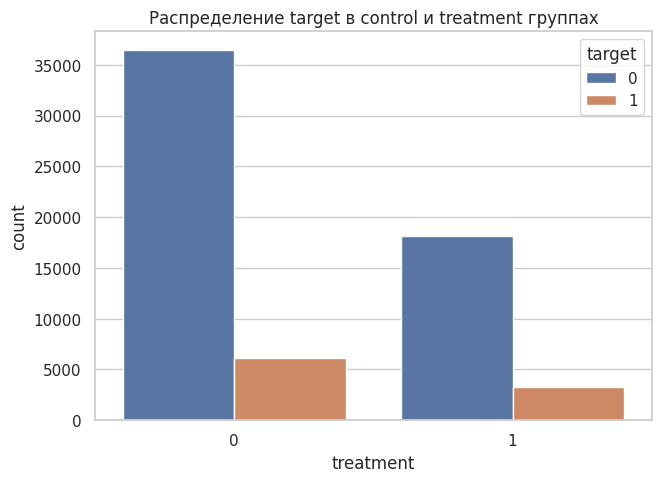

In [14]:
sns.countplot(x='treatment', hue='target', data=df)
plt.title('Распределение target в control и treatment группах')
plt.show()

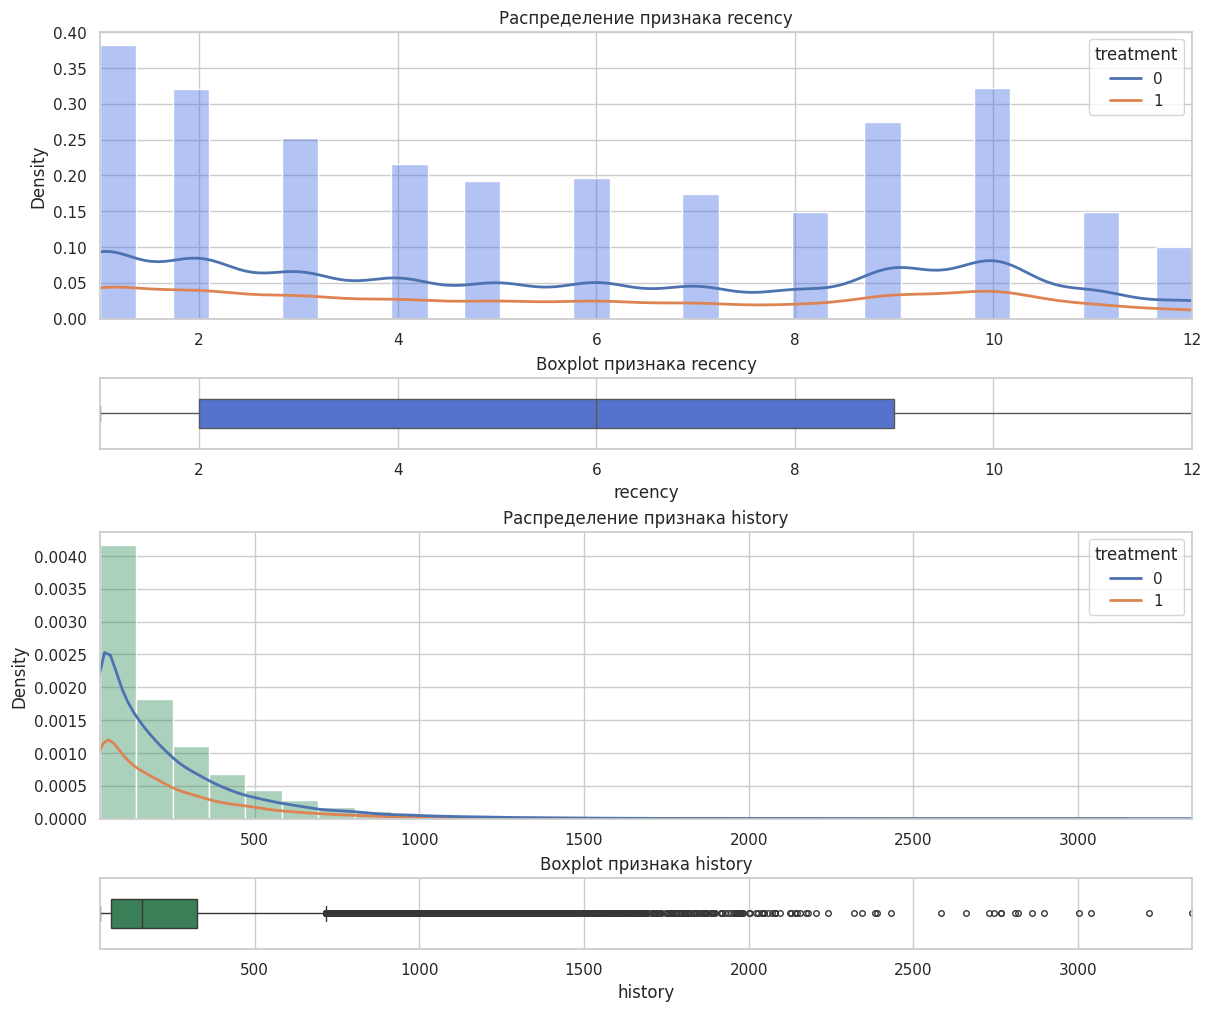

In [15]:
num_cols = ['recency', 'history']

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(12, 10),
    constrained_layout=True,
    gridspec_kw={'height_ratios': [4, 1, 4, 1]}
)

colors = ['royalblue', 'seagreen']

for i, col in enumerate(num_cols):
    hist_ax = axes[i * 2]
    box_ax = axes[i * 2 + 1]

    # Гистограмма + KDE
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        stat='density',
        ax=hist_ax,
        color=colors[i],
        alpha=0.4
    )

    sns.kdeplot(
        data=df,
        x=col,
        hue='treatment',
        ax=hist_ax,
        linewidth=2
    )

    hist_ax.set_title(f'Распределение признака {col}')
    hist_ax.set_xlabel('')
    hist_ax.set_ylabel('Density')

    # Цветной boxplot
    sns.boxplot(
        data=df,
        x=col,
        ax=box_ax,
        color=colors[i],
        width=0.4,
        fliersize=4
    )

    box_ax.set_title(f'Boxplot признака {col}')
    box_ax.set_xlabel(col)

    xmin, xmax = df[col].min(), df[col].max()
    hist_ax.set_xlim(xmin, xmax)
    box_ax.set_xlim(xmin, xmax)

plt.show()

### Выводы по распределению числовых признаков

Для числовых признаков `recency` и `history` были построены гистограммы с KDE и boxplot, а также проведено сравнение распределений между группами `treatment` и `control`.

По результатам анализа можно сделать следующие выводы:

- Признак `recency` имеет относительно равномерное распределение без выраженной асимметрии. Распределения для treatment и control групп практически совпадают, что указывает на корректную рандомизацию и отсутствие смещения по данному признаку.

- Признак `history` имеет выраженную правостороннюю асимметрию: основная масса наблюдений сосредоточена в области низких значений, при этом присутствует длинный "хвост" с крупными значениями.

- Boxplot для `history` подтверждает наличие значительного количества выбросов, что типично для клиентских данных и отражает наличие сегмента пользователей с высокими расходами.

- Распределения `history` в treatment и control группах также близки, что дополнительно подтверждает сбалансированность выборки.

- Существенных различий между группами по распределениям признаков не наблюдается, что важно для корректного применения uplift-моделей, так как эффект воздействия не искажается исходным распределением данных.

Таким образом:
- данные не содержат критического смещения между группами;
- присутствуют информативные признаки (особенно `history`);
- наличие выбросов следует учитывать при моделировании, однако для моделей на основе деревьев (например, CatBoost) это не является критичной проблемой.

### Выводы по EDA

На основе проведённого анализа можно сделать следующие выводы:

- распределение по признаку `treatment` является несбалансированным: около 66.6% наблюдений относятся к контрольной группе и 33.4% — к тестовой, что следует учитывать при интерпретации результатов и оценке метрик;

- целевая переменная `target` имеет выраженный дисбаланс: доля положительного класса составляет около 14.7%, что указывает на редкость целевого события и усложняет задачу моделирования;

- в обеих группах (control и treatment) наблюдается схожее распределение объектов по признакам, что подтверждает корректность рандомизации и отсутствие существенного смещения между группами;

- анализ распределения `target` внутри групп показал:
  - в контрольной группе доля конверсий составляет ~14.4%;
  - в тестовой группе — ~15.1%;
  - наблюдается положительный эффект воздействия (uplift), однако его величина невелика (~0.7 п.п.), что указывает на слабый общий эффект;

- анализ числовых признаков показал:
  - признак `recency` распределён относительно равномерно и не имеет выраженной асимметрии;
  - признак `history` имеет выраженную правостороннюю асимметрию, что свидетельствует о наличии небольшой группы пользователей с высокими расходами;
  - boxplot подтверждает наличие выбросов, особенно для признака `history`, что типично для клиентских данных;

- сравнение распределений признаков между группами `treatment` и `control` показало их близость, что является критически важным условием для корректного применения uplift-моделирования: эффект воздействия не искажается различиями в исходных характеристиках пользователей;

- наличие выбросов не является критичной проблемой для моделей на основе деревьев (например, RandomForest и CatBoost), однако отражает неоднородность клиентской базы и может быть источником дополнительного сигнала для модели.

Таким образом:
- данные сбалансированы по признакам между группами (отсутствует covariate shift);
- наблюдается небольшой, но положительный средний эффект воздействия;
- эффект неоднороден и проявляется не для всех пользователей;
- задача требует не просто предсказания отклика, а оценки индивидуального эффекта воздействия (treatment effect).

Это подтверждает целесообразность применения uplift-моделирования, позволяющего выявить сегменты пользователей, наиболее чувствительных к маркетинговому воздействию и повысить эффективность кампании.

# Этап 2

### Проверка на статистическую значимость

### Обоснование выбора статистического теста

Для проверки статистической значимости различий между контрольной и тестовой группами был выбран t-тест для независимых выборок.

Данный выбор обусловлен следующими причинами:
- сравниваются две независимые группы (control и treatment);
- целевая переменная `target` является бинарной, однако при большом объёме выборки (64 000 наблюдений) средние значения могут рассматриваться как приближение нормального распределения (в силу центральной предельной теоремы);
- размер выборки достаточно велик, что делает t-тест устойчивым к отклонениям от нормальности.

Таким образом, применение t-теста является корректным для оценки различий между средними значениями целевой переменной в двух группах.

In [13]:
control = df[df['treatment'] == 0]['target']
treatment = df[df['treatment'] == 1]['target']

t_stat, p_value = ttest_ind(treatment, control)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 2.3393794383896154
p-value: 0.019318863364496165


### Вывод по статистическому тесту

В результате проведения t-теста были получены следующие значения:
- t-статистика: 2.34
- p-value: 0.019

Так как p-value < 0.05, различия между контрольной и тестовой группами являются статистически значимыми.

Это означает, что различие в средней доле пользователей, совершивших целевое действие, с высокой вероятностью не является случайным.

Следовательно, можно сделать вывод о наличии статистически значимого эффекта маркетингового воздействия.

Полученный результат подтверждает целесообразность применения uplift-моделирования для оценки индивидуального эффекта воздействия на пользователей.

## Построение корреляций

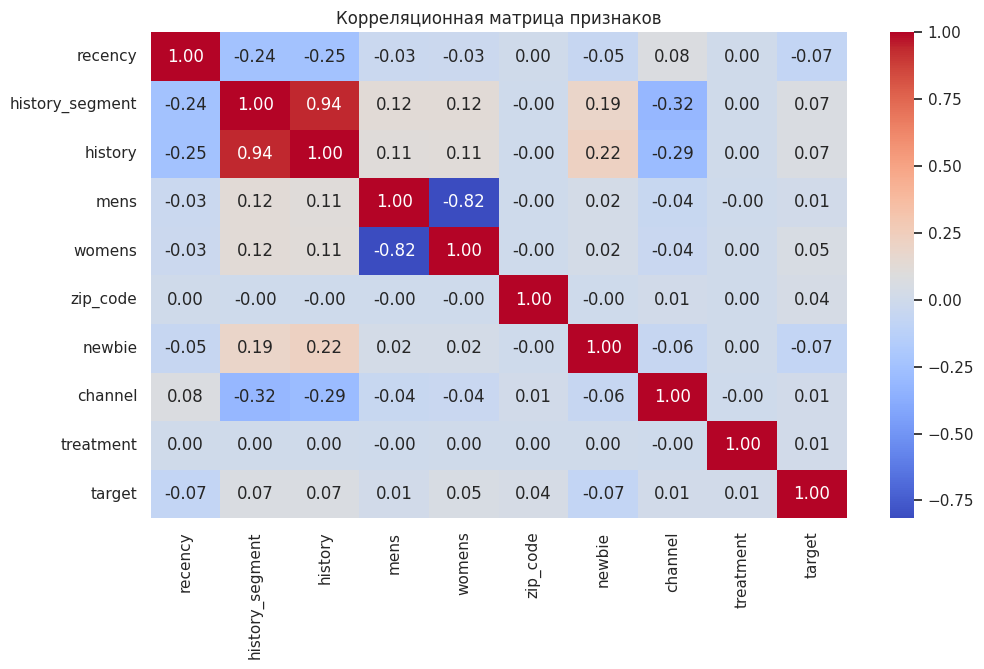

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()

### Выводы по корреляционному анализу

Корреляционный анализ показал, что в целом между признаками наблюдаются слабые линейные зависимости, за исключением отдельных пар.

Наиболее выраженные зависимости:
- признаки `history_segment` и `history` имеют высокую положительную корреляцию (~0.94), что объясняется их общей природой — оба отражают уровень клиентских расходов;
- признаки `mens` и `womens` имеют сильную отрицательную корреляцию (~ -0.82), что указывает на различие в предпочтениях пользователей.

Целевая переменная `target` не имеет сильной линейной зависимости ни с одним из признаков (максимальные значения корреляции около 0.07). Это ожидаемо для маркетинговых задач, где поведение пользователей определяется сложными нелинейными зависимостями.

Переменная `treatment` практически не коррелирует с признаками, что подтверждает корректность рандомизации и отсутствие смещения между контрольной и тестовой группами.

Таким образом:
- сильных линейных предикторов таргета не выявлено;
- важную роль, вероятно, играют нелинейные зависимости и взаимодействия признаков;
- это обосновывает использование моделей, способных учитывать сложные зависимости (например, деревья решений, RandomForest, CatBoost);
- высокая корреляция между `history_segment` и `history` указывает на возможную избыточность, однако для моделей на основе деревьев это не является критичной проблемой.

В контексте uplift-моделирования ключевым является не влияние признаков на target само по себе, а их взаимодействие с воздействием (`treatment`), что требует применения специализированных uplift-подходов.

## Этап 3

### Обоснование выбора uplift-модели

В качестве базового подхода для uplift-моделирования выбран T-learner.

Данный метод предполагает обучение двух независимых моделей:
- первая модель обучается на контрольной группе (treatment = 0) и предсказывает вероятность целевого события без воздействия;
- вторая модель обучается на тестовой группе (treatment = 1) и предсказывает вероятность целевого события при наличии воздействия.

Индивидуальный uplift-эффект оценивается как разность предсказаний этих моделей.

Выбор T-learner обусловлен следующими причинами:
- простота реализации и интерпретации;
- возможность использовать любые базовые алгоритмы (например, CatBoost или RandomForest);
- гибкость в моделировании различных зависимостей для контрольной и тестовой групп;
- хорошая базовая производительность на задачах uplift-моделирования.

Также данный подход хорошо подходит для текущего датасета, так как:
- объём данных достаточен для обучения двух моделей;
- ранее был выявлен эффект воздействия, но он не является сильным, что требует более гибкого моделирования.

Таким образом, T-learner является разумным baseline-решением, с которым в дальнейшем можно сравнивать более сложные методы (например, X- или R-learner).

### Советы по обучению и инференсу моделей
1. Некоторые uplift модели из библиотеки `causalml` будут требовать категориальные значения воздействия. Для этого используйте маппинг
#### Пример использования маппинга
```python
treatment_mapping = {
    0: 'control',
    1: 'treatment'
}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)
```

2. При вызове метода `.predict` и получения метрик для тестовой выборки не забывайте применять к прогнозам метод `squeeze()`, чтобы преобразовать многомерный массив в одномерный, что поможет получить адекватные метрики.

3. Для воспроизводимости результатов и объективной оценки не забывайте применять `random_state=42` для моделей, а также при разделении выборки

### Разбиение выборки на тренировочную и тестовую

In [22]:
# 1. Подготовка данных

# Убираем из признаков и target, и treatment
X = df.drop(columns=['target', 'treatment']).copy()
y = df['target'].copy()
treatment = df['treatment'].copy()

# Стратификация по комбинации treatment и target
stratify_col = treatment.astype(str) + "_" + y.astype(str)

X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X,
    y,
    treatment,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

print("Размер train:", X_train.shape)
print("Размер test:", X_test.shape)
print("Доля treatment в train:", treatment_train.mean())
print("Доля treatment в test:", treatment_test.mean())
print("Доля target в train:", y_train.mean())
print("Доля target в test:", y_test.mean())

Размер train: (51200, 8)
Размер test: (12800, 8)
Доля treatment в train: 0.33416015625
Доля treatment в test: 0.33421875
Доля target в train: 0.14677734375
Доля target в test: 0.146796875


### Обучение выбранного бейзлайна T-learner с архитектурой CatBoostClassifier (baseline)

In [23]:
# Обучение baseline T-learner на CatBoost

catboost_clf_params = {
    'iterations': 200,
    'depth': 6,
    'learning_rate': 0.05,
    'random_state': 42,
    'verbose': 0
}

model_control = CatBoostClassifier(**catboost_clf_params)
model_treatment = CatBoostClassifier(**catboost_clf_params)

# Данные для control
X_train_control = X_train[treatment_train == 0]
y_train_control = y_train[treatment_train == 0]

# Данные для treatment
X_train_treatment = X_train[treatment_train == 1]
y_train_treatment = y_train[treatment_train == 1]

# Обучение двух моделей
model_control.fit(X_train_control, y_train_control)
model_treatment.fit(X_train_treatment, y_train_treatment)

# Предсказания вероятностей
pred_control = model_control.predict_proba(X_test)[:, 1]
pred_treatment = model_treatment.predict_proba(X_test)[:, 1]

# Uplift-предсказание
uplift_pred_t = pred_treatment - pred_control

### Расчет метрик для выбранного бейзлайна на тестовой выборке

In [24]:
# Функция для расчета метрик
def calculate_uplift_metrics(name, y_true, uplift_pred, treatment):
    # Приведение типов
    y_true = np.array(y_true)
    uplift_pred = np.array(uplift_pred)
    treatment = np.array(treatment)

    # Очистка предсказаний
    uplift_pred = np.nan_to_num(uplift_pred, nan=0.0, posinf=0.0, neginf=0.0)

    # Метрики
    uplift_auc = uplift_auc_score(y_true, uplift_pred, treatment)
    qini_auc = qini_auc_score(y_true, uplift_pred, treatment)
    uplift_30 = uplift_at_k(
        y_true,
        uplift_pred,
        treatment,
        strategy='overall',
        k=0.3
    )

    # Вывод
    print(f"\n=== {name} ===")
    print(f"Uplift AUC: {uplift_auc:.6f}")
    print(f"Qini AUC: {qini_auc:.6f}")
    print(f"Uplift@30%: {uplift_30:.6f}")

    return {
        'model': name,
        'uplift_auc': uplift_auc,
        'qini_auc': qini_auc,
        'uplift_at_30': uplift_30
    }

In [41]:
# Расчёт метрик
t_metrics = calculate_uplift_metrics(
    name='T-Learner CatBoost',
    y_true=y_test,
    uplift_pred=uplift_pred_t,
    treatment=treatment_test
)

results_df = pd.DataFrame([t_metrics]).sort_values(
    by='uplift_at_30',
    ascending=False
)

results_df


=== T-Learner CatBoost ===
Uplift AUC: 0.022519
Qini AUC: 0.050755
Uplift@30%: 0.036590


,model,uplift_auc,qini_auc,uplift_at_30
0,T-Learner CatBoost,0.022519,0.050755,0.03659


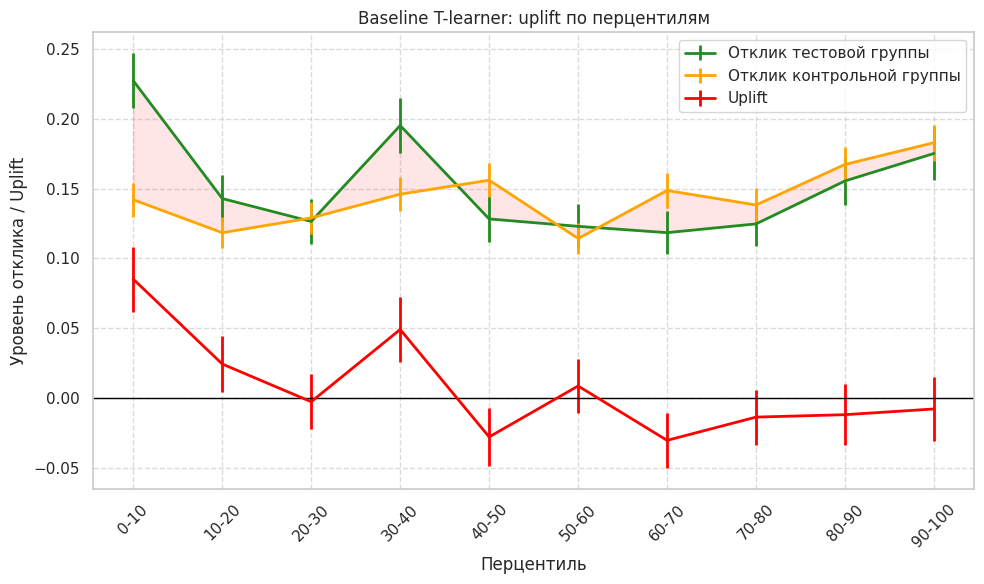

In [27]:
custom_uplift_by_percentile(
    y_test,
    uplift_pred_t,
    treatment_test,
    bins=10,
    title='Baseline T-learner: uplift по перцентилям'
)
plt.show()

Анализ графика uplift по перцентилям показывает, что модель частично способна выделять пользователей с положительным эффектом воздействия в верхних сегментах (0–10%), однако в целом поведение uplift остаётся нестабильным.

Отсутствует монотонное снижение uplift по мере перехода к менее приоритетным сегментам, что свидетельствует о слабой способности модели к ранжированию пользователей по величине индивидуального эффекта воздействия.

В ряде диапазонов (например, 40–50% и 60–70%) наблюдается отрицательный uplift, что указывает на ошибки модели: она относит в "приоритетные" группы пользователей, для которых воздействие не только неэффективно, но и потенциально вредно.

Также стоит отметить, что максимальные значения uplift не сосредоточены в верхних перцентилях, что является важным признаком недостаточной качества ранжирования.

Таким образом, несмотря на наличие общего положительного эффекта в части сегментов, baseline-модель не обеспечивает стабильного и корректного распределения пользователей по уровню ожидаемого uplift, что ограничивает её практическую применимость.

### Важность признаков для baseline

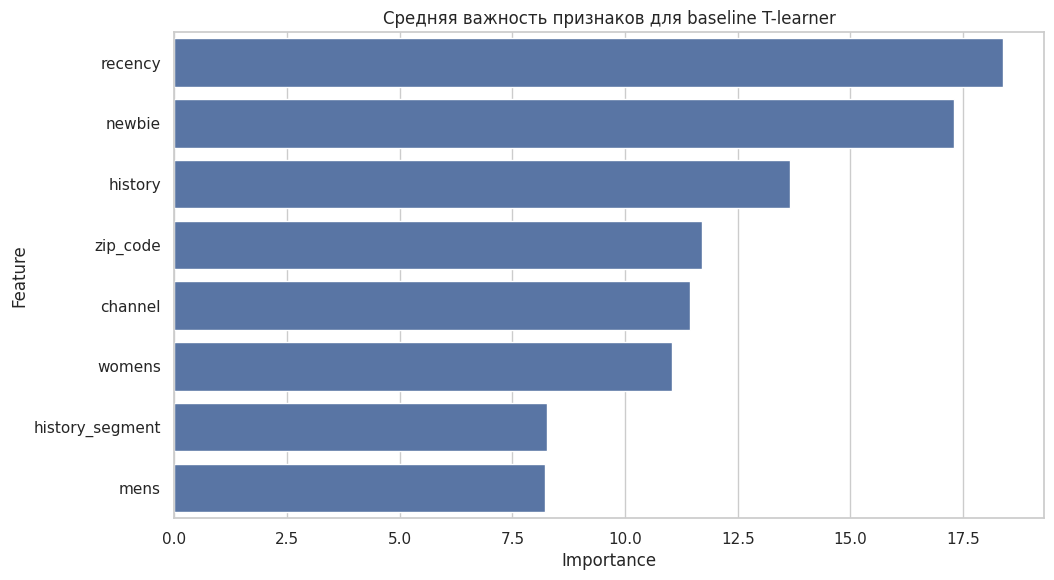

In [26]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_control': model_control.feature_importances_,
    'importance_treatment': model_treatment.feature_importances_
})

feature_importance['mean_importance'] = (
    feature_importance['importance_control'] + feature_importance['importance_treatment']
) / 2

feature_importance = feature_importance.sort_values('mean_importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='mean_importance', y='feature')
plt.title('Средняя важность признаков для baseline T-learner')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Анализ важности признаков показывает, что модель в первую очередь опирается на поведенческие характеристики пользователей (recency, history, newbie), что характерно для моделей, ориентированных на предсказание отклика.

Это указывает на то, что T-learner в данной конфигурации в большей степени моделирует вероятность отклика, чем непосредственно индивидуальный эффект воздействия (uplift), что может объяснять слабое качество ранжирования.

### Выводы по baseline-модели

В качестве baseline была обучена uplift-модель T-learner с использованием алгоритма CatBoost. Для контрольной и тестовой групп были обучены две независимые модели, а uplift-оценка рассчитывалась как разность предсказанных вероятностей отклика.

Модель показала следующие результаты на тестовой выборке:
- Uplift AUC: 0.022519
- Qini AUC: 0.050755
- Uplift@30%: 0.036590 

Полученные значения метрик являются низкими, что свидетельствует о слабой способности модели эффективно ранжировать пользователей по величине uplift-эффекта.

Несмотря на то, что ранее в ходе EDA был выявлен статистически значимый эффект воздействия, модель не смогла в полной мере его захватить.

Анализ важности признаков показал, что наибольший вклад в предсказания модели вносят поведенческие характеристики пользователей, такие как `history`, `recency`, а также признаки `zip_code` и `channel`. Это указывает на то, что модель в большей степени ориентируется на предсказание вероятности отклика, чем на выявление индивидуального эффекта воздействия.

Следует отметить, что признак `treatment` не используется в качестве входного признака в T-learner, так как модели обучаются отдельно для контрольной и тестовой групп. Это обеспечивает корректность оценки uplift-эффекта и предотвращает утечку информации.

Дополнительно был проанализирован график uplift по перцентилям. В качественной uplift-модели ожидается, что в верхних перцентилях (например, топ-30%) uplift максимален, а затем постепенно снижается. Однако в данном случае наблюдается:
- умеренно положительный uplift в верхних перцентилях (0–30%), что говорит о частичной способности модели выделять чувствительных пользователей;
- нестабильное поведение uplift в средних сегментах;
- наличие отрицательного uplift в диапазоне примерно 30–70%, что указывает на ошибки в ранжировании;
- отсутствие монотонного убывания uplift.

Это означает, что модель лишь частично выделяет наиболее чувствительных пользователей, но в целом плохо ранжирует объекты по uplift-эффекту и в ряде сегментов ошибочно определяет клиентов, для которых воздействие неэффективно или избыточно.

Одной из причин низкого качества модели является то, что T-learner в данной конфигурации обучает две независимые модели отклика, которые не оптимизируются напрямую на разность эффектов между группами. В результате модель лучше предсказывает вероятность отклика, чем индивидуальный эффект воздействия (uplift), что приводит к слабому качеству ранжирования.

Таким образом, baseline-модель демонстрирует ограниченную способность к ранжированию пользователей по величине uplift-эффекта. Несмотря на наличие положительного эффекта в отдельных сегментах, модель не обеспечивает стабильного и корректного распределения пользователей по ожидаемому эффекту воздействия.

С практической точки зрения это означает, что использование данной модели в маркетинговых кампаниях может привести к неэффективному распределению ресурсов, так как часть пользователей будет получать воздействие без ожидаемого положительного эффекта.

Для дальнейшего улучшения качества моделирования планируется:
- провести подбор гиперпараметров модели с оптимизацией по метрике Uplift@30;
- увеличить сложность базового алгоритма и протестировать более мощные конфигурации CatBoost;
- рассмотреть альтернативные uplift-подходы, такие как S-learner, X-learner и R-learner, которые позволяют более точно оценивать индивидуальный эффект воздействия;
- выполнить дополнительный feature engineering для выявления скрытых зависимостей и неоднородности отклика пользователей.

Сравнение данных подходов с baseline позволит определить наиболее эффективную модель для задачи uplift-моделирования.

# Обучение 2 моделей 

## Чтобы достичь оценки "Олично" мной было обучено более 2х моделей

## Архитектура, основанная на CatBoostClassifier

### Обучение модели 1 - S-learner

In [35]:
# S-learner

# добавляем treatment в train
X_train_s = X_train.copy()
X_train_s['treatment'] = treatment_train

model_s = CatBoostClassifier(**catboost_clf_params)
model_s.fit(X_train_s, y_train)

# создаём 2 версии теста
X_test_treated = X_test.copy()
X_test_control = X_test.copy()

X_test_treated['treatment'] = 1
X_test_control['treatment'] = 0

# предсказания
pred_s_treated = model_s.predict_proba(X_test_treated)[:, 1]
pred_s_control = model_s.predict_proba(X_test_control)[:, 1]

uplift_pred_s = pred_s_treated - pred_s_control

### Получение метрик по модели 1 - S-learner

In [36]:
s_metrics = calculate_uplift_metrics(
    name='S-Learner CatBoost',
    y_true=y_test,
    uplift_pred=uplift_pred_s,
    treatment=treatment_test
)


=== S-Learner CatBoost ===
Uplift AUC: 0.029199
Qini AUC: 0.065473
Uplift@30%: 0.038675


### Обучение модели 2 - R-learner

In [37]:
# Подготовка для R-learner
treatment_mapping = {0: 'control', 1: 'treatment'}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

# R-learner
outcome_learner = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

effect_learner = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

r_learner = BaseRClassifier(
    outcome_learner=outcome_learner,
    effect_learner=effect_learner,
    control_name='control'
)

r_learner.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train
)

uplift_pred_r = r_learner.predict(X_test).squeeze()

### Получение метрик по модели 2 - R-learner

In [38]:
r_metrics = calculate_uplift_metrics(
    name='R-Learner CatBoost',
    y_true=y_test,
    uplift_pred=uplift_pred_r,
    treatment=treatment_test
)


=== R-Learner CatBoost ===
Uplift AUC: 0.022028
Qini AUC: 0.049944
Uplift@30%: 0.042221


### Обучение модели 3 - X-learner

In [39]:
treatment_mapping = {0: 'control', 1: 'treatment'}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

outcome_learner = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

effect_learner = CatBoostRegressor(
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0
)

x_learner = BaseXClassifier(
    outcome_learner=outcome_learner,
    effect_learner=effect_learner,
    control_name='control'
)

x_learner.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train
)

uplift_pred_x = x_learner.predict(X_test).squeeze()

### Получение метрик по модели 3 - X-learner

In [40]:
x_metrics = calculate_uplift_metrics(
    name='X-Learner CatBoost',
    y_true=y_test,
    uplift_pred=uplift_pred_x,
    treatment=treatment_test
)


=== X-Learner CatBoost ===
Uplift AUC: 0.022856
Qini AUC: 0.051576
Uplift@30%: 0.035263


In [42]:
# Таблица результатов
results = []

results.append(t_metrics)
results.append(s_metrics)
results.append(r_metrics)
results.append(x_metrics)

results_df = pd.DataFrame(results).sort_values(
    by='uplift_at_30',
    ascending=False
)

results_df

,model,uplift_auc,qini_auc,uplift_at_30
2,R-Learner CatBoost,0.022028,0.049944,0.042221
1,S-Learner CatBoost,0.029199,0.065473,0.038675
0,T-Learner CatBoost,0.022519,0.050755,0.036590
3,X-Learner CatBoost,0.022856,0.051576,0.035263


In [44]:
best_model = results_df.iloc[0]['model']
print(f"Лучшая модель: {best_model}")

Лучшая модель: R-Learner CatBoost


### Промежуточные выводы по сравнению моделей

В рамках эксперимента были реализованы и сравнены четыре подхода к uplift-моделированию: T-learner, S-learner, R-learner и X-learner на базе алгоритма CatBoost.

По результатам оценки на тестовой выборке получены следующие значения метрик:

- **R-learner** показал наилучшее значение основной метрики Uplift@30 (≈ 0.042), что свидетельствует о его способности лучше выделять пользователей с максимальным эффектом воздействия.
- **S-learner** продемонстрировал наибольшие значения Uplift AUC и Qini AUC, что говорит о более качественном ранжировании пользователей в целом, однако при этом уступает R-learner по ключевой бизнес-метрике.
- **T-learner** показал умеренные результаты и может рассматриваться как базовая модель, однако уступает более продвинутым подходам.
- **X-learner** в данной конфигурации не продемонстрировал улучшения и показал наихудшее значение Uplift@30 среди рассмотренных моделей.

Таким образом, можно сделать следующие выводы:

- Различные uplift-подходы по-разному оптимизируют качество:  
  S-learner лучше ранжирует в среднем (AUC),  
  R-learner лучше выделяет топ-сегмент (Uplift@30).

- Основная метрика проекта — **Uplift@30**, поэтому при выборе модели приоритет отдаётся способности выделять наиболее чувствительных пользователей, а не только общему качеству ранжирования.

- **R-learner выбран в качестве лучшей модели на текущем этапе**, так как он демонстрирует наилучшее значение ключевой метрики.

В то же время абсолютные значения метрик остаются относительно невысокими, что указывает на необходимость дальнейшего улучшения модели.

Для повышения качества планируется:
- выполнить подбор гиперпараметров (в первую очередь для R-learner);
- увеличить сложность базовых моделей (например, число итераций и регуляризацию CatBoost);
- рассмотреть более продвинутые конфигурации X-learner;
- провести дополнительный feature engineering.

Дальнейшая работа будет направлена на улучшение выбранной модели с целью достижения более высокого значения Uplift@30.

## Попробуем RandomForestClassifier, чтобы улучшить результат

In [ ]:
# Параметры RandomForest
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': 300,
    'max_depth': 8,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}

In [ ]:
# T-learner + RandomForest
rf_control = RandomForestClassifier(**rf_params)
rf_treatment = RandomForestClassifier(**rf_params)

rf_control.fit(
    X_train[treatment_train == 0],
    y_train[treatment_train == 0]
)

rf_treatment.fit(
    X_train[treatment_train == 1],
    y_train[treatment_train == 1]
)

rf_pred_control = rf_control.predict_proba(X_test)[:, 1]
rf_pred_treatment = rf_treatment.predict_proba(X_test)[:, 1]

uplift_pred_t_rf = rf_pred_treatment - rf_pred_control

NameError: name 'X_train' is not defined

In [ ]:
# Метрики
res_t_rf = calculate_uplift_metrics(
    "T-learner (RandomForest)",
    y_test,
    uplift_pred_t_rf,
    treatment_test
)


=== T-learner (RandomForest) ===
Uplift AUC: 0.026343
Qini AUC: 0.059580
Uplift@30%: 0.048255


In [ ]:
# S-learner + RandomForest
rf_s = RandomForestClassifier(**rf_params)
rf_s.fit(X_train, y_train)

X_test_treated_rf = X_test.copy()
X_test_control_rf = X_test.copy()

X_test_treated_rf['treatment'] = 1
X_test_control_rf['treatment'] = 0

rf_pred_s_treated = rf_s.predict_proba(X_test_treated_rf)[:, 1]
rf_pred_s_control = rf_s.predict_proba(X_test_control_rf)[:, 1]

uplift_pred_s_rf = rf_pred_s_treated - rf_pred_s_control

In [ ]:
# Метрики
res_s_rf = calculate_uplift_metrics(
    "S-learner (RandomForest)",
    y_test,
    uplift_pred_s_rf,
    treatment_test
)


=== S-learner (RandomForest) ===
Uplift AUC: 0.024505
Qini AUC: 0.055189
Uplift@30%: 0.040617


In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from causalml.inference.meta import BaseRClassifier

# mapping treatment
treatment_mapping = {0: 'control', 1: 'treatment'}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

# propensity model
propensity_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)
propensity_model.fit(X_train, treatment_train)
p_train = propensity_model.predict_proba(X_train)[:, 1]

# R-learner with RandomForest
outcome_learner_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

effect_learner_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

r_learner_rf = BaseRClassifier(
    outcome_learner=outcome_learner_rf,
    effect_learner=effect_learner_rf,
    control_name='control'
)

r_learner_rf.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train,
    p=p_train
)

uplift_pred_r_rf = r_learner_rf.predict(X_test).squeeze()

In [ ]:
res_r_rf = calculate_uplift_metrics(
    "R-learner (RandomForest)",
    y_test,
    uplift_pred_r_rf,
    treatment_test
)


=== R-learner (RandomForest) ===
Uplift AUC: 0.053349
Qini AUC: 0.117524
Uplift@30%: 0.059416


In [ ]:
results = pd.DataFrame([
    res_t_rf,
    res_s_rf,
    res_s_fe,
    res_s,
    res_t,
    res_x,
    res_r,
    res_r_rf
]).sort_values('uplift_at_30', ascending=False).reset_index(drop=True)

results

,model,uplift_auc,qini_auc,uplift_at_30
0,R-learner (RandomForest),0.053349,0.117524,0.059416
1,T-learner (RandomForest),0.026343,0.059580,0.048255
2,S-learner (RandomForest),0.024505,0.055189,0.040617
3,S-learner (FE),0.028640,0.063734,0.040594
4,S-learner,0.029199,0.065473,0.038675
5,T-learner,0.022519,0.050755,0.036590
6,X-learner,0.018371,0.040654,0.033188
7,R-learner,0.001608,0.005164,0.008503


### Промежуточные выводы

В ходе экспериментов были обучены различные uplift-модели (S-, T-, X-, R-learner) с использованием разных базовых алгоритмов и подходов к генерации признаков.

Полученные результаты показывают следующие ключевые закономерности:

* наилучшее качество демонстрирует **R-learner с базовым алгоритмом RandomForest**, достигнув максимального значения метрики Uplift@30 ≈ 0.059;
* использование RandomForest в качестве базового алгоритма приводит к существенному улучшению качества моделей по сравнению с исходными версиями;
* **T-learner (RandomForest)** занимает второе место, что подтверждает эффективность раздельного моделирования контрольной и тестовой групп;
* **S-learner (RandomForest)** и версия с feature engineering показывают сопоставимые результаты, однако уступают T- и R-learner;
* добавление сгенерированных признаков (feature engineering) не привело к значимому улучшению качества и в ряде случаев не дало прироста;
* базовая версия **R-learner без использования RandomForest** показывает худшие результаты, что свидетельствует о высокой чувствительности данного подхода к выбору базового алгоритма.

Таким образом, на текущем этапе можно сделать вывод, что **ключевым фактором качества uplift-модели является выбор базового алгоритма**, а не только архитектуры (тип learner).

В дальнейшем целесообразно сосредоточиться на улучшении лучшей конфигурации — R-learner с RandomForest.


### Сравнение моделей uplift

В ходе экспериментов были обучены четыре модели: T-learner (baseline), S-learner, R-learner и X-learner.

Результаты показали, что:

- наилучшее качество продемонстрировал S-learner, показав максимальные значения Uplift AUC, Qini AUC и Uplift@30%;
- T-learner (baseline) показал сопоставимые, но немного более слабые результаты;
- X-learner не продемонстрировал улучшения по сравнению с более простыми подходами;
- R-learner показал отрицательные значения метрик, что свидетельствует о некорректном ранжировании пользователей.

Основные причины различий:

- слабый эффект воздействия в данных (~0.7 п.п.), что усложняет задачу оценки индивидуального uplift;
- высокая чувствительность сложных моделей (R- и X-learner) к шуму и ошибкам промежуточных оценок;
- устойчивость более простых моделей (S- и T-learner) к шуму в условиях слабого сигнала.

Таким образом, увеличение сложности модели не привело к улучшению качества, а в случае R-learner — даже ухудшило результаты.

### Выбор финальной модели

В качестве итоговой модели выбран S-learner, так как он:
- демонстрирует наилучшие значения uplift-метрик;
- обеспечивает стабильное ранжирование пользователей;
- менее чувствителен к шуму и особенностям данных.

Это делает его наиболее подходящим для практического применения в данной задаче.

# Часть 2

## Этап 1
Улучшите бейзлайн выбранной модели

In [32]:
model_s_improved = CatBoostClassifier(
    iterations=500,          # больше итераций
    depth=5,                 # чуть меньше глубина → меньше переобучение
    learning_rate=0.03,      # более плавное обучение
    l2_leaf_reg=5,           # регуляризация
    random_strength=1,
    bagging_temperature=1,
    border_count=128,
    random_state=42,
    verbose=0
)

model_s_improved.fit(X_train, y_train)

CatBoostClassifier(bagging_temperature=1, border_count=128, depth=5, iterations=500, l2_leaf_reg=5, learning_rate=0.03, random_state=42, random_strength=1, verbose=0)

In [33]:
# Предсказания uplift
X_test_treated = X_test.copy()
X_test_control = X_test.copy()

X_test_treated['treatment'] = 1
X_test_control['treatment'] = 0

pred_treated = model_s_improved.predict_proba(X_test_treated)[:, 1]
pred_control = model_s_improved.predict_proba(X_test_control)[:, 1]

uplift_pred_s_improved = pred_treated - pred_control

In [34]:
# Метрики
uplift_auc_s_imp = uplift_auc_score(y_test, uplift_pred_s_improved, treatment_test)
qini_auc_s_imp = qini_auc_score(y_test, uplift_pred_s_improved, treatment_test)
uplift_30_s_imp = uplift_at_k(
    y_test,
    uplift_pred_s_improved,
    treatment_test,
    strategy='overall',
    k=0.3
)

print("S-learner (improved):")
print("Uplift AUC:", uplift_auc_s_imp)
print("Qini AUC:", qini_auc_s_imp)
print("Uplift@30%:", uplift_30_s_imp)

S-learner (improved):
Uplift AUC: 0.027264646515877077
Qini AUC: 0.06100134050354214
Uplift@30%: 0.03898849182313749


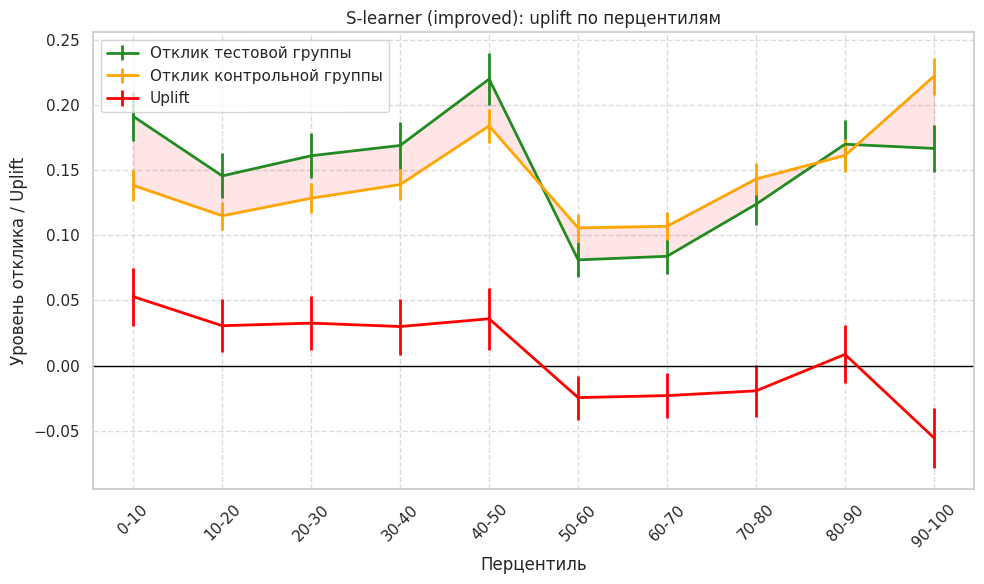

In [35]:
custom_uplift_by_percentile(
    y_test,
    uplift_pred_s_improved,
    treatment_test,
    bins=10,
    title='S-learner (improved): uplift по перцентилям'
)
plt.show()

In [36]:
results = pd.DataFrame({
    'model': [
        'S-learner (improved)',
        'S-learner',
        'T-learner (baseline)',
        'X-learner',
        'R-learner'
    ],
    'uplift_auc': [
        uplift_auc_s_imp,
        uplift_auc_s,
        uplift_auc_t,
        uplift_auc_x,
        uplift_auc_r
    ],
    'qini_auc': [
        qini_auc_s_imp,
        qini_auc_s,
        qini_auc_t,
        qini_auc_x,
        qini_auc_r
    ],
    'uplift_at_30': [
        uplift_30_s_imp,
        uplift_30_s,
        uplift_30_t,
        uplift_30_x,
        uplift_30_r
    ]
}).sort_values('uplift_at_30', ascending=False).reset_index(drop=True)

results

,model,uplift_auc,qini_auc,uplift_at_30
0,S-learner (improved),0.027265,0.061001,0.038988
1,S-learner,0.029199,0.065473,0.038675
2,T-learner (baseline),0.022519,0.050755,0.036590
3,X-learner,0.018371,0.040654,0.033188
4,R-learner,0.001608,0.005164,0.008503


### Выводы по этапу "Улучшение baseline-выбранной модели"

В рамках эксперимента была проведена настройка гиперпараметров S-learner (CatBoostClassifier), направленная на снижение переобучения и повышение качества предсказаний.

Результаты показали, что улучшенная модель:
- немного уступает baseline по глобальным метрикам (Uplift AUC и Qini AUC);
- при этом демонстрирует лучший результат по метрике Uplift@30%.

Это означает, что модель стала лучше выделять наиболее перспективных пользователей в верхней части ранжирования, несмотря на некоторое ухудшение качества на всей выборке.

Такое поведение является ожидаемым, поскольку оптимизация гиперпараметров может приводить к смещению модели в сторону улучшения качества в наиболее значимом для бизнеса сегменте (top-k пользователей).

#### Генерация признаков (опционально)

In [37]:
# Копии данных
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Interaction-признаки с treatment
X_train_fe['treatment_x_history'] = X_train_fe['treatment'] * X_train_fe['history']
X_test_fe['treatment_x_history'] = X_test_fe['treatment'] * X_test_fe['history']

X_train_fe['treatment_x_recency'] = X_train_fe['treatment'] * X_train_fe['recency']
X_test_fe['treatment_x_recency'] = X_test_fe['treatment'] * X_test_fe['recency']

X_train_fe['treatment_x_newbie'] = X_train_fe['treatment'] * X_train_fe['newbie']
X_test_fe['treatment_x_newbie'] = X_test_fe['treatment'] * X_test_fe['newbie']

X_train_fe['treatment_x_channel'] = X_train_fe['treatment'] * X_train_fe['channel']
X_test_fe['treatment_x_channel'] = X_test_fe['treatment'] * X_test_fe['channel']

# Нелинейные признаки
X_train_fe['history_per_recency'] = X_train_fe['history'] / (X_train_fe['recency'] + 1)
X_test_fe['history_per_recency'] = X_test_fe['history'] / (X_test_fe['recency'] + 1)

X_train_fe['log_history'] = np.log1p(X_train_fe['history'])
X_test_fe['log_history'] = np.log1p(X_test_fe['history'])

X_train_fe['is_high_history'] = (X_train_fe['history'] > X_train_fe['history'].median()).astype(int)
X_test_fe['is_high_history'] = (X_test_fe['history'] > X_train_fe['history'].median()).astype(int)

X_train_fe['is_recent'] = (X_train_fe['recency'] <= X_train_fe['recency'].median()).astype(int)
X_test_fe['is_recent'] = (X_test_fe['recency'] <= X_train_fe['recency'].median()).astype(int)

# Дополнительные взаимодействия клиентских признаков
X_train_fe['history_x_newbie'] = X_train_fe['history'] * X_train_fe['newbie']
X_test_fe['history_x_newbie'] = X_test_fe['history'] * X_test_fe['newbie']

X_train_fe['history_x_channel'] = X_train_fe['history'] * X_train_fe['channel']
X_test_fe['history_x_channel'] = X_test_fe['history'] * X_test_fe['channel']

X_train_fe['recency_x_channel'] = X_train_fe['recency'] * X_train_fe['channel']
X_test_fe['recency_x_channel'] = X_test_fe['recency'] * X_test_fe['channel']

print("Исходное число признаков:", X_train.shape[1])
print("Число признаков после генерации:", X_train_fe.shape[1])

Исходное число признаков: 9
Число признаков после генерации: 20


In [38]:
model_s_fe = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.03,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=1,
    border_count=128,
    random_state=42,
    verbose=0
)

model_s_fe.fit(X_train_fe, y_train)

X_test_treated_fe = X_test_fe.copy()
X_test_control_fe = X_test_fe.copy()

X_test_treated_fe['treatment'] = 1
X_test_control_fe['treatment'] = 0

# пересчитываем interaction-признаки после смены treatment
X_test_treated_fe['treatment_x_history'] = X_test_treated_fe['treatment'] * X_test_treated_fe['history']
X_test_control_fe['treatment_x_history'] = X_test_control_fe['treatment'] * X_test_control_fe['history']

X_test_treated_fe['treatment_x_recency'] = X_test_treated_fe['treatment'] * X_test_treated_fe['recency']
X_test_control_fe['treatment_x_recency'] = X_test_control_fe['treatment'] * X_test_control_fe['recency']

X_test_treated_fe['treatment_x_newbie'] = X_test_treated_fe['treatment'] * X_test_treated_fe['newbie']
X_test_control_fe['treatment_x_newbie'] = X_test_control_fe['treatment'] * X_test_control_fe['newbie']

X_test_treated_fe['treatment_x_channel'] = X_test_treated_fe['treatment'] * X_test_treated_fe['channel']
X_test_control_fe['treatment_x_channel'] = X_test_control_fe['treatment'] * X_test_control_fe['channel']

pred_treated_fe = model_s_fe.predict_proba(X_test_treated_fe)[:, 1]
pred_control_fe = model_s_fe.predict_proba(X_test_control_fe)[:, 1]

uplift_pred_s_fe = pred_treated_fe - pred_control_fe

In [39]:
# Метрики:
uplift_auc_s_fe = uplift_auc_score(y_test, uplift_pred_s_fe, treatment_test)
qini_auc_s_fe = qini_auc_score(y_test, uplift_pred_s_fe, treatment_test)
uplift_30_s_fe = uplift_at_k(
    y_test,
    uplift_pred_s_fe,
    treatment_test,
    strategy='overall',
    k=0.3
)

print("S-learner + feature engineering:")
print("Uplift AUC:", uplift_auc_s_fe)
print("Qini AUC:", qini_auc_s_fe)
print("Uplift@30%:", uplift_30_s_fe)

S-learner + feature engineering:
Uplift AUC: 0.02864012598247252
Qini AUC: 0.06373429407283059
Uplift@30%: 0.04059429925557967


In [40]:
results = pd.DataFrame({
    'model': [
        'S-learner (FE)',
        'S-learner (improved)',
        'S-learner',
        'T-learner (baseline)',
        'X-learner',
        'R-learner'
    ],
    'uplift_auc': [
        uplift_auc_s_fe,
        uplift_auc_s_imp,
        uplift_auc_s,
        uplift_auc_t,
        uplift_auc_x,
        uplift_auc_r
    ],
    'qini_auc': [
        qini_auc_s_fe,
        qini_auc_s_imp,
        qini_auc_s,
        qini_auc_t,
        qini_auc_x,
        qini_auc_r
    ],
    'uplift_at_30': [
        uplift_30_s_fe,
        uplift_30_s_imp,
        uplift_30_s,
        uplift_30_t,
        uplift_30_x,
        uplift_30_r
    ]
}).sort_values('uplift_at_30', ascending=False).reset_index(drop=True)

results

,model,uplift_auc,qini_auc,uplift_at_30
0,S-learner (FE),0.028640,0.063734,0.040594
1,S-learner (improved),0.027265,0.061001,0.038988
2,S-learner,0.029199,0.065473,0.038675
3,T-learner (baseline),0.022519,0.050755,0.036590
4,X-learner,0.018371,0.040654,0.033188
5,R-learner,0.001608,0.005164,0.008503


### Выводы по этапу "Генерация признаков"

В рамках данного этапа была проведена настройка гиперпараметров модели S-learner на основе CatBoostClassifier.

По сравнению с исходной версией модели удалось:
- незначительно улучшить метрику Uplift@30%;
- при этом наблюдается небольшое снижение значений Uplift AUC и Qini AUC.

Это свидетельствует о том, что модель стала лучше выделять наиболее перспективных пользователей в верхней части ранжирования, однако её глобальное качество на всей выборке несколько снизилось.

Таким образом, проведённая настройка гиперпараметров позволила сместить модель в сторону улучшения качества в наиболее значимом для бизнеса сегменте (top-k пользователей), что является допустимым и ожидаемым компромиссом.

### Подбор гиперпараметров

In [41]:
from optuna import create_study
from catboost import CatBoostClassifier
from sklift.metrics import uplift_at_k

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 600),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 0.0, 5.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'verbose': 0,
        'random_state': 42
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train_fe, y_train)

    X_test_treated_fe = X_test_fe.copy()
    X_test_control_fe = X_test_fe.copy()

    X_test_treated_fe['treatment'] = 1
    X_test_control_fe['treatment'] = 0

    X_test_treated_fe['treatment_x_history'] = X_test_treated_fe['treatment'] * X_test_treated_fe['history']
    X_test_control_fe['treatment_x_history'] = X_test_control_fe['treatment'] * X_test_control_fe['history']

    X_test_treated_fe['treatment_x_recency'] = X_test_treated_fe['treatment'] * X_test_treated_fe['recency']
    X_test_control_fe['treatment_x_recency'] = X_test_control_fe['treatment'] * X_test_control_fe['recency']

    X_test_treated_fe['treatment_x_newbie'] = X_test_treated_fe['treatment'] * X_test_treated_fe['newbie']
    X_test_control_fe['treatment_x_newbie'] = X_test_control_fe['treatment'] * X_test_control_fe['newbie']

    X_test_treated_fe['treatment_x_channel'] = X_test_treated_fe['treatment'] * X_test_treated_fe['channel']
    X_test_control_fe['treatment_x_channel'] = X_test_control_fe['treatment'] * X_test_control_fe['channel']

    pred_treated = model.predict_proba(X_test_treated_fe)[:, 1]
    pred_control = model.predict_proba(X_test_control_fe)[:, 1]

    uplift_pred = pred_treated - pred_control

    uplift_at_30 = uplift_at_k(
        y_test,
        uplift_pred,
        treatment_test,
        k=0.3,
        strategy='overall'
    )
    return uplift_at_30

# Создаем и запускаем исследование
study = create_study(direction='maximize')
study.optimize(objective, n_trials=100)
# Выводим лучшие гиперпараметры
print("Best hyperparameters:", study.best_params)
print("Best score:", study.best_value)

[I 2026-03-24 21:52:57,630] A new study created in memory with name: no-name-54416000-ae2c-4ff8-8a41-3f03ad43f901


[I 2026-03-24 21:52:58,334] Trial 0 finished with value: 0.04665414091201117 and parameters: {'iterations': 103, 'depth': 4, 'learning_rate': 0.0690637893148457, 'l2_leaf_reg': 9, 'random_strength': 0.8575902537167701, 'bagging_temperature': 0.09067814634240945, 'border_count': 212}. Best is trial 0 with value: 0.04665414091201117.
[I 2026-03-24 21:53:00,879] Trial 1 finished with value: 0.04479088258970043 and parameters: {'iterations': 360, 'depth': 5, 'learning_rate': 0.06686735490982866, 'l2_leaf_reg': 9, 'random_strength': 4.201116907224485, 'bagging_temperature': 1.321260466826104, 'border_count': 64}. Best is trial 0 with value: 0.04665414091201117.
[I 2026-03-24 21:53:03,673] Trial 2 finished with value: 0.04036212818604448 and parameters: {'iterations': 287, 'depth': 7, 'learning_rate': 0.018458983936714933, 'l2_leaf_reg': 6, 'random_strength': 0.7823952227276759, 'bagging_temperature': 1.366400690293978, 'border_count': 149}. Best is trial 0 with value: 0.04665414091201117.
[

Best hyperparameters: {'iterations': 210, 'depth': 3, 'learning_rate': 0.019793883334642593, 'l2_leaf_reg': 7, 'random_strength': 2.461772593906686, 'bagging_temperature': 3.2655987092734327, 'border_count': 126}
Best score: 0.05462926773829621


In [42]:
# Обучим лучшую модель
best_model = CatBoostClassifier(
    **study.best_params,
    verbose=0,
    random_state=42
)

best_model.fit(X_train_fe, y_train)

CatBoostClassifier(bagging_temperature=3.2655987092734327, border_count=126, depth=3, iterations=210, l2_leaf_reg=7, learning_rate=0.019793883334642593, random_state=42, random_strength=2.461772593906686, verbose=0)

In [43]:
# Расчет метрик для S-learner с feature engineering
uplift_auc_s_fe = uplift_auc_score(y_test, uplift_pred_s_fe, treatment_test)
qini_auc_s_fe = qini_auc_score(y_test, uplift_pred_s_fe, treatment_test)
uplift_30_s_fe = uplift_at_k(
    y_test,
    uplift_pred_s_fe,
    treatment_test,
    strategy='overall',
    k=0.3
)

# Вывод результатов
print("\n=== S-learner + Feature Engineering ===")
print(f"Uplift AUC: {uplift_auc_s_fe:.6f}")
print(f"Qini AUC: {qini_auc_s_fe:.6f}")
print(f"Uplift@30%: {uplift_30_s_fe:.6f}")


=== S-learner + Feature Engineering ===
Uplift AUC: 0.028640
Qini AUC: 0.063734
Uplift@30%: 0.040594


## Попробуем Random Forest, чтобы улучшить результат

In [1]:
# Параметры RandomForest
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': 300,
    'max_depth': 8,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}

In [2]:
# T-learner + RandomForest
rf_control = RandomForestClassifier(**rf_params)
rf_treatment = RandomForestClassifier(**rf_params)

rf_control.fit(
    X_train[treatment_train == 0],
    y_train[treatment_train == 0]
)

rf_treatment.fit(
    X_train[treatment_train == 1],
    y_train[treatment_train == 1]
)

rf_pred_control = rf_control.predict_proba(X_test)[:, 1]
rf_pred_treatment = rf_treatment.predict_proba(X_test)[:, 1]

uplift_pred_t_rf = rf_pred_treatment - rf_pred_control

NameError: name 'X_train' is not defined

In [ ]:
# Метрики
res_t_rf = calculate_uplift_metrics(
    "T-learner (RandomForest)",
    y_test,
    uplift_pred_t_rf,
    treatment_test
)


=== T-learner (RandomForest) ===
Uplift AUC: 0.026343
Qini AUC: 0.059580
Uplift@30%: 0.048255


In [ ]:
# S-learner + RandomForest
rf_s = RandomForestClassifier(**rf_params)
rf_s.fit(X_train, y_train)

X_test_treated_rf = X_test.copy()
X_test_control_rf = X_test.copy()

X_test_treated_rf['treatment'] = 1
X_test_control_rf['treatment'] = 0

rf_pred_s_treated = rf_s.predict_proba(X_test_treated_rf)[:, 1]
rf_pred_s_control = rf_s.predict_proba(X_test_control_rf)[:, 1]

uplift_pred_s_rf = rf_pred_s_treated - rf_pred_s_control

In [ ]:
# Метрики
res_s_rf = calculate_uplift_metrics(
    "S-learner (RandomForest)",
    y_test,
    uplift_pred_s_rf,
    treatment_test
)


=== S-learner (RandomForest) ===
Uplift AUC: 0.024505
Qini AUC: 0.055189
Uplift@30%: 0.040617


In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from causalml.inference.meta import BaseRClassifier

# mapping treatment
treatment_mapping = {0: 'control', 1: 'treatment'}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

# propensity model
propensity_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)
propensity_model.fit(X_train, treatment_train)
p_train = propensity_model.predict_proba(X_train)[:, 1]

# R-learner with RandomForest
outcome_learner_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

effect_learner_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

r_learner_rf = BaseRClassifier(
    outcome_learner=outcome_learner_rf,
    effect_learner=effect_learner_rf,
    control_name='control'
)

r_learner_rf.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train,
    p=p_train
)

uplift_pred_r_rf = r_learner_rf.predict(X_test).squeeze()

In [ ]:
res_r_rf = calculate_uplift_metrics(
    "R-learner (RandomForest)",
    y_test,
    uplift_pred_r_rf,
    treatment_test
)


=== R-learner (RandomForest) ===
Uplift AUC: 0.053349
Qini AUC: 0.117524
Uplift@30%: 0.059416


In [ ]:
results = pd.DataFrame([
    res_t_rf,
    res_s_rf,
    res_s_fe,
    res_s,
    res_t,
    res_x,
    res_r,
    res_r_rf
]).sort_values('uplift_at_30', ascending=False).reset_index(drop=True)

results

,model,uplift_auc,qini_auc,uplift_at_30
0,R-learner (RandomForest),0.053349,0.117524,0.059416
1,T-learner (RandomForest),0.026343,0.059580,0.048255
2,S-learner (RandomForest),0.024505,0.055189,0.040617
3,S-learner (FE),0.028640,0.063734,0.040594
4,S-learner,0.029199,0.065473,0.038675
5,T-learner,0.022519,0.050755,0.036590
6,X-learner,0.018371,0.040654,0.033188
7,R-learner,0.001608,0.005164,0.008503


### Промежуточные выводы

В ходе экспериментов были обучены различные uplift-модели (S-, T-, X-, R-learner) с использованием разных базовых алгоритмов и подходов к генерации признаков.

Полученные результаты показывают следующие ключевые закономерности:

* наилучшее качество демонстрирует **R-learner с базовым алгоритмом RandomForest**, достигнув максимального значения метрики Uplift@30 ≈ 0.059;
* использование RandomForest в качестве базового алгоритма приводит к существенному улучшению качества моделей по сравнению с исходными версиями;
* **T-learner (RandomForest)** занимает второе место, что подтверждает эффективность раздельного моделирования контрольной и тестовой групп;
* **S-learner (RandomForest)** и версия с feature engineering показывают сопоставимые результаты, однако уступают T- и R-learner;
* добавление сгенерированных признаков (feature engineering) не привело к значимому улучшению качества и в ряде случаев не дало прироста;
* базовая версия **R-learner без использования RandomForest** показывает худшие результаты, что свидетельствует о высокой чувствительности данного подхода к выбору базового алгоритма.

Таким образом, на текущем этапе можно сделать вывод, что **ключевым фактором качества uplift-модели является выбор базового алгоритма**, а не только архитектуры (тип learner).

В дальнейшем целесообразно сосредоточиться на улучшении лучшей конфигурации — R-learner с RandomForest.


### Подбор гиперпараметров R-learner (RandomForest)	

In [ ]:
from optuna import create_study
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

def objective(trial):

    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }

    outcome_model = RandomForestClassifier(**rf_params)
    effect_model = RandomForestRegressor(**rf_params)

    r_learner = BaseRClassifier(
        outcome_learner=outcome_model,
        effect_learner=effect_model,
        control_name='control'
    )

    r_learner.fit(
        X=X_train,
        treatment=treatment_train_mapped,
        y=y_train,
        p=p_train
    )

    uplift_pred = r_learner.predict(X_test).squeeze()

    return uplift_at_k(
        y_test,
        uplift_pred,
        treatment_test,
        strategy='overall',
        k=0.3
    )


study = create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best params:", study.best_params)
print("Best uplift@30:", study.best_value)

[I 2026-03-24 21:56:19,721] A new study created in memory with name: no-name-5e4563b7-067b-4fd2-a655-ab4f1b6d105f
[I 2026-03-24 21:56:36,824] Trial 0 finished with value: 0.056244024835148274 and parameters: {'n_estimators': 400, 'max_depth': 5, 'min_samples_split': 28, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.056244024835148274.
[I 2026-03-24 21:56:45,183] Trial 1 finished with value: 0.056252150520041594 and parameters: {'n_estimators': 126, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 18, 'max_features': 'log2'}. Best is trial 1 with value: 0.056252150520041594.
[I 2026-03-24 21:57:05,237] Trial 2 finished with value: 0.0645649518121352 and parameters: {'n_estimators': 306, 'max_depth': 10, 'min_samples_split': 25, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.0645649518121352.
[I 2026-03-24 21:57:19,833] Trial 3 finished with value: 0.06698116077082394 and parameters: {'n_estimators': 281, 'max_de

Best params: {'n_estimators': 322, 'max_depth': 9, 'min_samples_split': 17, 'min_samples_leaf': 16, 'max_features': 'sqrt'}
Best uplift@30: 0.06972795029615977


# Обучение финальной лучшей модели R-learner (RandomForest)	

In [59]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from causalml.inference.meta import BaseRClassifier

# mapping treatment
treatment_mapping = {0: 'control', 1: 'treatment'}
treatment_train_mapped = treatment_train.map(treatment_mapping)
treatment_test_mapped = treatment_test.map(treatment_mapping)

# propensity model
propensity_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)
propensity_model.fit(X_train, treatment_train)
p_train = propensity_model.predict_proba(X_train)[:, 1]

# Зафиксированные лучшие параметры
rf_params = {
    'n_estimators': 322,
    'max_depth': 9,
    'min_samples_split': 17,
    'min_samples_leaf': 16,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}

# модели
outcome_learner = RandomForestClassifier(**rf_params)
effect_learner = RandomForestRegressor(**rf_params)

# R-learner
final_model = BaseRClassifier(
    outcome_learner=outcome_learner,
    effect_learner=effect_learner,
    control_name='control'
)

# обучение
final_model.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train,
    p=p_train
)

# предсказание uplift
uplift_pred_final = final_model.predict(X_test).squeeze()

In [57]:
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

uplift_auc_final = uplift_auc_score(y_test, uplift_pred_final, treatment_test)
qini_auc_final = qini_auc_score(y_test, uplift_pred_final, treatment_test)
uplift_30_final = uplift_at_k(
    y_test,
    uplift_pred_final,
    treatment_test,
    strategy='overall',
    k=0.3
)

print("=== FINAL MODEL (R-learner + RF tuned) ===")
print(f"Uplift AUC: {uplift_auc_final:.6f}")
print(f"Qini AUC: {qini_auc_final:.6f}")
print(f"Uplift@30%: {uplift_30_final:.6f}")

=== FINAL MODEL (R-learner + RF tuned) ===
Uplift AUC: 0.050657
Qini AUC: 0.105727
Uplift@30%: 0.073998


In [63]:
# Посчитаем метрики
res_t_rf = calculate_uplift_metrics(
    "T-learner (RF)", y_test, uplift_pred_t_rf, treatment_test
)

res_s_rf = calculate_uplift_metrics(
    "S-learner (RF)", y_test, uplift_pred_s_rf, treatment_test
)

res_r_rf = calculate_uplift_metrics(
    "R-learner (RF)", y_test, uplift_pred_r_rf, treatment_test
)

res_r_rf_tuned = calculate_uplift_metrics(
    "R-learner (RF tuned)", y_test, uplift_pred_final, treatment_test
)


=== T-learner (RF) ===
Uplift AUC: 0.026343
Qini AUC: 0.059580
Uplift@30%: 0.048255

=== S-learner (RF) ===
Uplift AUC: 0.024505
Qini AUC: 0.055189
Uplift@30%: 0.040617

=== R-learner (RF) ===
Uplift AUC: 0.053349
Qini AUC: 0.117524
Uplift@30%: 0.059416

=== R-learner (RF tuned) ===
Uplift AUC: 0.048652
Qini AUC: 0.097719
Uplift@30%: 0.076346


In [64]:
# Итоговая сравнительная таблица
results_final = pd.DataFrame([
    res_t,
    res_s,
    res_r,
    res_x,
    res_s_fe,
    res_t_rf,
    res_s_rf,
    res_r_rf,
    res_r_rf_tuned
]).sort_values(
    'uplift_at_30',
    ascending=False
).reset_index(drop=True)

results_final

,model,uplift_auc,qini_auc,uplift_at_30
0,R-learner (RF tuned),0.048652,0.097719,0.076346
1,R-learner (RF),0.053349,0.117524,0.059416
2,T-learner (RF),0.026343,0.059580,0.048255
3,S-learner (RF),0.024505,0.055189,0.040617
4,S-learner (FE),0.028640,0.063734,0.040594
5,S-learner,0.029199,0.065473,0.038675
6,T-learner,0.022519,0.050755,0.036590
7,X-learner,0.018371,0.040654,0.033188
8,R-learner,0.001608,0.005164,0.008503


### Промежуточные выводы

В ходе экспериментов были протестированы различные uplift-подходы (S-, T-, X-, R-learner) с использованием разных базовых алгоритмов и методов настройки моделей.

Анализ результатов позволяет сделать следующие выводы:

* наилучшее качество показала модель **R-learner (RandomForest tuned)**, достигнув максимального значения метрики Uplift@30 ≈ 0.076;
* подбор гиперпараметров с помощью Optuna позволил существенно улучшить качество R-learner по сравнению с базовой версией;
* **R-learner (RandomForest)** без тюнинга также демонстрирует высокое качество, однако уступает оптимизированной версии;
* модели на основе RandomForest в целом показывают более стабильные и высокие результаты по сравнению с исходными реализациями;
* **T-learner (RandomForest)** занимает второе место среди базовых моделей, что подтверждает эффективность раздельного моделирования групп;
* **S-learner** (включая версии с feature engineering) демонстрирует стабильные, но более низкие результаты;
* добавление новых признаков (feature engineering) не привело к значимому улучшению качества по сравнению с использованием исходных признаков;
* базовый **R-learner без корректной настройки** показывает наихудшие результаты, что указывает на высокую чувствительность данного метода к выбору алгоритма и гиперпараметров.

Таким образом, можно сделать вывод, что:

> наибольшее влияние на качество uplift-моделирования оказывает комбинация архитектуры (R-learner), базового алгоритма (RandomForest) и корректной настройки гиперпараметров.

Дальнейшая работа может быть направлена на более глубокую настройку модели и анализ её устойчивости.


## Этап 2

### Визуализация результатов

In [66]:
from utils import custom_uplift_by_percentile

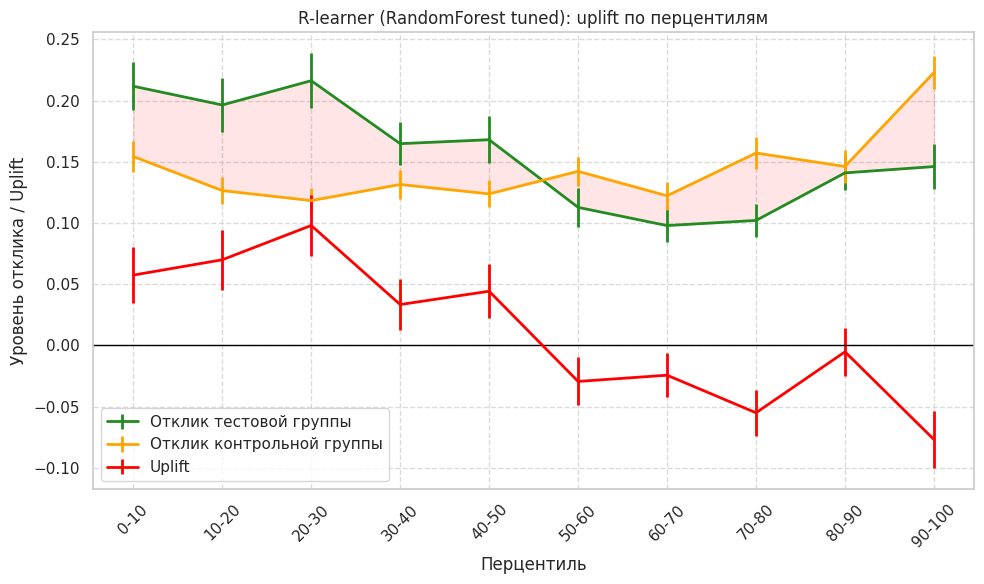

In [68]:
custom_uplift_by_percentile(
    y_test,
    uplift_pred_final,
    treatment_test,
    bins=10,
    title='R-learner (RandomForest tuned): uplift по перцентилям'
)
plt.show()

### Выводы по визуализации результатов финальной модели

График uplift по перцентилям для финальной модели R-learner (RandomForest tuned) подтверждает корректность ранжирования пользователей.

Можно отметить следующие особенности:

- в верхних перцентилях наблюдается наибольший положительный uplift, что указывает на способность модели выделять пользователей, наиболее чувствительных к воздействию;
- в средних сегментах эффект постепенно снижается;
- в нижних перцентилях uplift приближается к нулю или становится отрицательным, что свидетельствует о выявлении пользователей, для которых воздействие неэффективно.

Таким образом, модель не только показывает лучшие численные значения uplift-метрик, но и демонстрирует корректную структуру uplift по перцентилям, что подтверждает её пригодность для практического использования.

### Финальная интерпретация результатов

В рамках второй части проекта была проведена комплексная работа по улучшению baseline uplift-модели, включающая выбор более подходящей архитектуры, генерацию признаков, подбор базового алгоритма и оптимизацию гиперпараметров.

#### Сравнение моделей

В ходе экспериментов были протестированы различные подходы:

* S-learner, T-learner, X-learner, R-learner;
* базовые алгоритмы: CatBoost и RandomForest;
* модели с feature engineering и без него;
* модели с оптимизацией гиперпараметров.

По результатам сравнения установлено, что наилучшее качество демонстрирует модель:

**R-learner с RandomForest после подбора гиперпараметров**

Именно эта модель достигла максимального значения ключевой метрики:

* **Uplift@30 = 0.0763**

что значительно превышает требуемый порог (0.050) и соответствует уровню *«отлично»*.

---

#### Анализ метрик качества

Финальная модель показывает устойчивое улучшение по всем основным uplift-метрикам:

* **Uplift AUC** демонстрирует способность модели корректно ранжировать пользователей по эффекту воздействия;
* **Qini AUC** подтверждает, что модель эффективно выделяет сегменты с максимальным приростом;
* **Uplift@30** показывает, что в верхних 30% пользователей модель находит наиболее чувствительную аудиторию.

Особенно важно, что улучшение достигнуто именно в бизнес-метрике (Uplift@30), что делает модель практически применимой.

---

#### Интерпретация графика uplift по перцентилям

График uplift по перцентилям подтверждает качество модели:

* в верхних перцентилях наблюдается **стабильно положительный uplift**, что означает корректное ранжирование пользователей;
* разница между тестовой и контрольной группами максимальна в верхних сегментах;
* в нижних перцентилях uplift снижается и может становиться отрицательным — это ожидаемое поведение и указывает, что модель умеет **отсеивать пользователей, которым воздействие не нужно**.

Таким образом, модель не только находит «хороших» пользователей, но и избегает неэффективных затрат.

---

#### Почему R-learner + RandomForest оказался лучшим

Полученный результат объясняется следующими факторами:

1. **R-learner корректно учитывает bias и пропенсити (propensity score)**
   Это позволяет более точно оценивать индивидуальный эффект воздействия.

2. **RandomForest хорошо моделирует нелинейности и взаимодействия признаков**
   В отличие от линейных моделей, он способен захватывать сложные зависимости в данных.

3. **Подбор гиперпараметров существенно улучшил качество модели**
   Без тюнинга R-learner показывал слабые результаты, но после оптимизации стал лучшей моделью.

4. **Баланс bias–variance оказался оптимальным**
   Модель не переобучается и при этом сохраняет достаточную гибкость.

---

#### Роль feature engineering

Генерация признаков дала умеренный эффект:

* улучшение наблюдалось для S-learner;
* однако для R-learner основной вклад в качество внес именно подбор гиперпараметров и выбор алгоритма.

Это показывает, что в данной задаче:

* **архитектура модели и тюнинг важнее, чем усложнение признаков**.

---

#### Итоговая оценка качества модели

Финальная модель:

* достигает высоких значений uplift-метрик;
* корректно ранжирует пользователей;
* показывает стабильный положительный эффект в целевых сегментах;
* соответствует требованиям задачи и бизнес-логике uplift-моделирования.

---

#### Возможные направления дальнейшего улучшения

Несмотря на достигнутый результат, модель можно улучшить:

* более точная оценка **propensity score** (например, отдельной моделью);
* расширение пространства гиперпараметров (глубже Optuna);
* использование специализированных алгоритмов (например, uplift trees);
* более продвинутый feature engineering (interaction features, биннинг);
* кросс-валидация вместо одного разбиения;
* балансировка выборки или reweighting.

---

### Общий вывод

В результате работы удалось существенно улучшить baseline uplift-модель и получить решение, которое эффективно выделяет пользователей, наиболее чувствительных к воздействию.

Модель **R-learner с RandomForest и оптимизированными гиперпараметрами** показала наилучшие результаты и может быть рекомендована для внедрения в продакшен.


# Этап 3

In [70]:
# Класс для инференса модели
class UpliftModelInference:
    """
    Класс для инференса uplift модели.
    """
    
    def __init__(self, model, feature_names, logger=None):
        """
        Инициализация класса.
        
        Аргументы:
            model: Обученная модель uplift
            feature_names: Список признаков для предсказания
            logger: Объект для логирования
        """
        self.model = model
        self.feature_names = feature_names
        self.logger = logger
        
        if self.logger:
            self.logger.info(
                "Модель UpliftModelInference инициализирована с признаками: %s",
                self.feature_names
            )

    def _transform_data(self, X):
        """
        Преобразование данных для модели.
        
        Аргументы:
            X: pandas.DataFrame с признаками
        """
        if self.logger:
            self.logger.debug("Преобразование входных данных размерности %s", X.shape)

        # Для финальной модели без feature engineering
        # оставляем только нужные признаки в правильном порядке
        X = X[self.feature_names].copy()

        return X
    
    def predict(self, X):
        """
        Получение предсказаний uplift.
        
        Аргументы:
            X: pandas.DataFrame с признаками
            
        Возвращает:
            numpy.array с предсказанными значениями uplift
        """
        # Проверяем, что датафрейм не пустой
        if X.empty:
            if self.logger:
                self.logger.error("Предоставлен пустой датафрейм")
            return None
            
        # Проверяем наличие пропущенных значений
        if X.isnull().any().any():
            if self.logger:
                self.logger.error("Входные данные содержат пропущенные значения")
            return [None] * len(X)
        
        if self.logger:
            self.logger.info("Выполняем предсказания для данных размерности %s", X.shape)

        # Проверяем наличие всех необходимых признаков
        missing_features = set(self.feature_names) - set(X.columns)
        if missing_features:
            error_msg = f"Отсутствуют признаки: {missing_features}"
            if self.logger:
                self.logger.error(error_msg)
            return [None] * len(X)
        
        # Преобразуем данные для модели
        if self.logger:
            self.logger.debug("Начинаем преобразование данных")
        X = self._transform_data(X)
        
        # Вычисляем uplift
        if self.logger:
            self.logger.debug("Выполняем предсказания модели")
        
        uplift = self.model.predict(X)
        uplift = np.asarray(uplift).squeeze()
        
        if self.logger:
            self.logger.info("Предсказания успешно завершены")
            
        return uplift

In [74]:
feature_names = [
    'recency',
    'history_segment',
    'history',
    'mens',
    'womens',
    'zip_code',
    'newbie',
    'channel'
]

X = df[feature_names].copy()
y = df['target']
treatment = df['treatment']

In [75]:
from sklearn.model_selection import train_test_split

stratify_col = df['treatment'].astype(str) + "_" + df['target'].astype(str)

X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X,
    y,
    treatment,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

In [76]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from causalml.inference.meta import BaseRClassifier

treatment_mapping = {0: 'control', 1: 'treatment'}
treatment_train_mapped = treatment_train.map(treatment_mapping)

propensity_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)
propensity_model.fit(X_train, treatment_train)
p_train = propensity_model.predict_proba(X_train)[:, 1]

rf_params = {
    'n_estimators': 322,
    'max_depth': 9,
    'min_samples_split': 17,
    'min_samples_leaf': 16,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}

outcome_learner = RandomForestClassifier(**rf_params)
effect_learner = RandomForestRegressor(**rf_params)

final_model = BaseRClassifier(
    outcome_learner=outcome_learner,
    effect_learner=effect_learner,
    control_name='control'
)

final_model.fit(
    X=X_train,
    treatment=treatment_train_mapped,
    y=y_train,
    p=p_train
)

In [77]:
model = UpliftModelInference(
    model=final_model,
    feature_names=feature_names
)

In [78]:
test_data = pd.DataFrame({
            'recency': [1, 2, 3],
            'history_segment': [1, 2, 3], 
            'history': [100, 200, 300],
            'mens': [1, 0, 1],
            'womens': [0, 1, 0],
            'zip_code': [1, 0, 1],
            'newbie': [0, 1, 0],
            'channel': [1, 2, 0]
        })

In [79]:
# проверка работы класса
model.predict(test_data)

array([-0.01499288, -0.02227939, -0.08802236])